In [60]:
from pandas import read_csv
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [61]:
data=read_csv('international-airline-passengers.csv',usecols=[1])
print(data)


     International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
0                                                  112                             
1                                                  118                             
2                                                  132                             
3                                                  129                             
4                                                  121                             
..                                                 ...                             
139                                                606                             
140                                                508                             
141                                                461                             
142                                                390                             
143                                                432                      

In [62]:
data.describe()

,International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [63]:
values= data.values.astype('float32')
values.shape

(144, 1)

In [64]:
train_size=int(len(values)*0.67)
test_size=len(values)-train_size
print(train_size,test_size)

96 48


In [65]:
training=values[0:train_size,:]
test=values[train_size:len(values),:]
print(training.shape,test.shape)

(96, 1) (48, 1)


In [66]:
scaler=MinMaxScaler(feature_range=(0,1))
training_scaled=scaler.fit_transform(training)
test_scaled=scaler.transform(test)
print(training_scaled[1:5],test_scaled[1:5])

[[0.04530746]
 [0.09061491]
 [0.08090615]
 [0.05501619]] [[0.63754046]
 [0.815534  ]
 [0.7896441 ]
 [0.8122978 ]]


In [67]:
def create_dataset(dataset,look_back=1):
    dataX,dataY=[],[]
    for i in range(dataset.shape[0]-look_back):
        x=dataset[i:(i+look_back),0]
        y=dataset[i+look_back,0]
        dataX.append(x)
        dataY.append(y)
    return np.array(dataX),np.array(dataY)

In [68]:
look_back=12
trainX , trainY =create_dataset(training_scaled,look_back)
testX , testY =create_dataset(test_scaled,look_back)

print(trainX[1:5], trainY[1:5])


[[0.04530746 0.09061491 0.08090615 0.05501619 0.10032365 0.14239484
  0.14239484 0.10355988 0.04854369 0.         0.04530746 0.03559873]
 [0.09061491 0.08090615 0.05501619 0.10032365 0.14239484 0.14239484
  0.10355988 0.04854369 0.         0.04530746 0.03559873 0.07119742]
 [0.08090615 0.05501619 0.10032365 0.14239484 0.14239484 0.10355988
  0.04854369 0.         0.04530746 0.03559873 0.07119742 0.11974111]
 [0.05501619 0.10032365 0.14239484 0.14239484 0.10355988 0.04854369
  0.         0.04530746 0.03559873 0.07119742 0.11974111 0.10032365]] [0.07119742 0.11974111 0.10032365 0.06796119]


In [69]:
trainX = np.reshape(trainX,(trainX.shape[0],trainX.shape[1],1))
testX = np.reshape(testX,(testX.shape[0],testX.shape[1],1))
print(trainX.shape,trainY.shape,testX.shape,testY.shape)
print(trainX[1:5],trainY[1:5])

(84, 12, 1) (84,) (36, 12, 1) (36,)
[[[0.04530746]
  [0.09061491]
  [0.08090615]
  [0.05501619]
  [0.10032365]
  [0.14239484]
  [0.14239484]
  [0.10355988]
  [0.04854369]
  [0.        ]
  [0.04530746]
  [0.03559873]]

 [[0.09061491]
  [0.08090615]
  [0.05501619]
  [0.10032365]
  [0.14239484]
  [0.14239484]
  [0.10355988]
  [0.04854369]
  [0.        ]
  [0.04530746]
  [0.03559873]
  [0.07119742]]

 [[0.08090615]
  [0.05501619]
  [0.10032365]
  [0.14239484]
  [0.14239484]
  [0.10355988]
  [0.04854369]
  [0.        ]
  [0.04530746]
  [0.03559873]
  [0.07119742]
  [0.11974111]]

 [[0.05501619]
  [0.10032365]
  [0.14239484]
  [0.14239484]
  [0.10355988]
  [0.04854369]
  [0.        ]
  [0.04530746]
  [0.03559873]
  [0.07119742]
  [0.11974111]
  [0.10032365]]] [0.07119742 0.11974111 0.10032365 0.06796119]


In [70]:
from keras.models import Sequential
from keras.layers import Dense ,SimpleRNN

In [71]:
model = Sequential()

model.add(SimpleRNN(4,input_shape=(look_back,1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')
model.fit(trainX,trainY,epochs=100,batch_size=1)

Epoch 1/100


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step - loss: 0.2407 
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step - loss: 0.0627
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 431us/step - loss: 0.0393
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 426us/step - loss: 0.0298
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 427us/step - loss: 0.0243
Epoch 6/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step - loss: 0.0202
Epoch 7/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 426us/step - loss: 0.0179
Epoch 8/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 426us/step - loss: 0.0153
Epoch 9/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step - loss: 0.0142
Epoch 10/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 438us/step - loss: 0.0128
Epoch 11/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 431us/step - loss: 0.0119  
Epoch 12/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 426us/step - loss: 0.0112
Epoch 13/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 427us/step - loss: 0.0100
Epoch 14/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 423us/step - loss: 0.0098
Epoch 15/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/ste

In [72]:

testPredict = model.predict(testX)
testPredict = scaler.inverse_transform(testPredict)

trainPredict = model.predict(trainX)
trainPredict = scaler.inverse_transform(trainPredict)

testTrue= scaler.inverse_transform([testY])
trainTrue= scaler.inverse_transform([trainY])

testPredict.shape, trainPredict.shape, testTrue.shape, trainTrue.shape


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


((36, 1), (84, 1), (1, 36), (1, 84))

In [73]:
import matplotlib.pyplot as plt

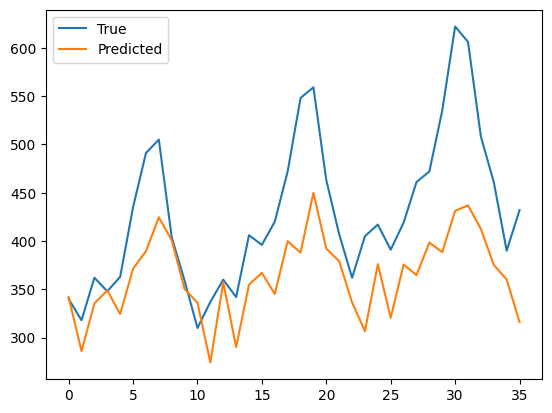

In [74]:
plt.plot(testTrue[0],label='True')
plt.plot(testPredict[:,0],label='Predicted')
plt.legend()
plt.show()

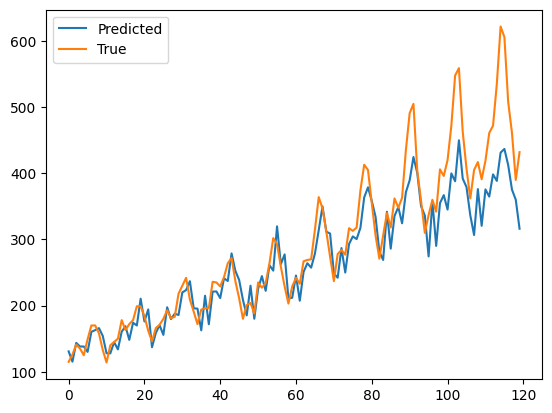

In [77]:
combinePredicted = np.concatenate((trainPredict[:,0], testPredict[:,0]))
combineTrue = np.concatenate((trainTrue[0], testTrue[0]))

plt.plot(combinePredicted, label='Predicted')
plt.plot(combineTrue, label='True')
plt.legend()
plt.show()